## Pseudo slices generation

The datasets used for this tutorial is the reconstruction of the mouse embryo‘s heart and can be downloaded at:

https://drive.google.com/file/d/1pY5ykd99AY7ciUiOpxyr0-n7j2YgPoyt/view?usp=sharing

In [1]:
import unist
import scanpy as sc

In [ ]:
### if you encounter: initialized module 'pyvista' has no attribute '_plot', try this
%cd /UniST
!python scripts/patch_pyvista_circular_import.py

In [2]:
import pyvista as pv

In [3]:
from unist.downstream.vis.slice_generation import (
    slice_points_plane,
    generate_slice_origins,
    slice_stack,
    plot_slice_stack,
)
from unist.downstream.vis import construct_pc, three_d_plot

In [ ]:
### read in our reconstructed heart data
adata = sc.read("path to reconstructed heart data")
adata

AnnData object with n_obs × n_vars = 77239 × 0
    obs: 'heart_regions', 'slices', 'stage', '3d_spatial_density_heart_regions'
    obsm: 'aligned_spatial_3D'
    layers: 'total'

In [5]:
regions_colors = {
 'Left ventricle': '#a9373b',
 'Right ventricle': '#d49896',
 'Outflow tract': '#faf5f5',
 'Right atrium': '#9aadca',
 'Left atrium': '#2369bd'
}

In [6]:
pc, plot_cmap = construct_pc(adata=adata.copy(), spatial_key="aligned_spatial_3D", groupby="heart_regions", key_added="heart_regions", colormap=regions_colors)

In [13]:
cpo = [(5444.183304815099, -433.55114217077306, 332.768997337317),
 (661.4129333496094, 809.88232421875, 760.0),
 (0.08558340442504621, -0.013109568632835982, 0.9962447591316503)]

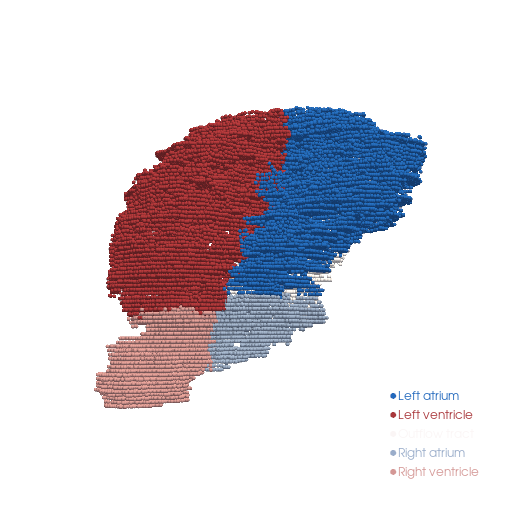

CameraPosition(position=(5444.183304815099, -433.55114217077306, 332.768997337317),
               focal_point=(661.4129333496094, 809.88232421875, 760.0),
               viewup=(0.08558340442504621, -0.013109568632835982, 0.9962447591316503))

In [16]:
three_d_plot(
    model=pc,
    key="heart_regions",                      
    model_style="points",
    model_size=4.0,
    show_legend=True,
    jupyter="static",
    cpo=cpo,
    opacity=1,
)

### Generate multi-planar virtual sections

In [14]:
cpo = [(5825.277464512356, 2749.6486846176085, 728.5799955884356),
 (671.4129333496094, 1009.88232421875, 750.0),
 (0.029166943582168467, -0.07413095778616903, 0.996821895074431)]

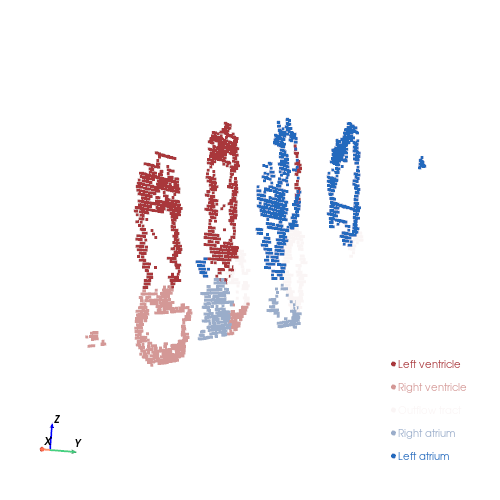

CameraPosition(position=(5825.277464512356, 2749.6486846176085, 728.5799955884356),
               focal_point=(671.4129333496094, 1009.88232421875, 750.0),
               viewup=(0.029166943582168467, -0.07413095778616903, 0.996821895074431))

In [15]:
# generate 6 plane of the point cloud pc along the y-axis
slices = slice_stack(pc, normal=(0,1,0), n_slices=6, width=20, margin=0.0)

plot_slice_stack(
    slices,
    key="heart_regions",
    regions_colors=regions_colors,
    point_size=2.5,
    opacity=1.0,
    spacing_axis=1,
    spacing=80.0,
    use_parallel_projection=False,
    window_size=(500, 500),
    show_legend=True,
    jupyter="static",
    cpo = cpo
)

In [21]:
cpo = [(1861.8655260948804, -3900.5710278071024, 1148.9430379922371),
 (661.4129333496094, 1049.88232421875, 760.0),
 (-0.0016356004190787136, 0.0779314826800191, 0.9969573756277463)]

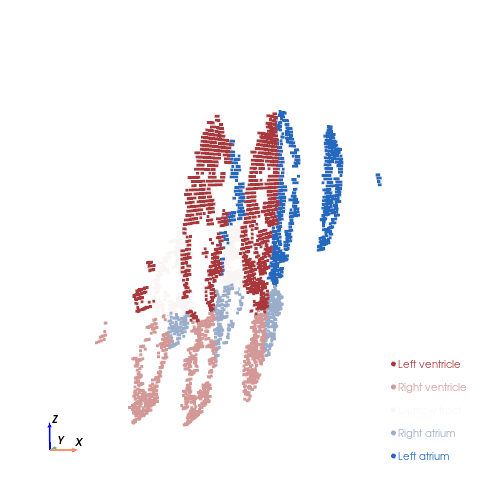

CameraPosition(position=(1861.8655260948804, -3900.5710278071024, 1148.9430379922371),
               focal_point=(661.4129333496094, 1049.88232421875, 760.0),
               viewup=(-0.0016356004190787132, 0.07793148268001909, 0.9969573756277461))

In [22]:
# generate 6 plane of the point cloud pc along the x-axis
slices = slice_stack(pc, normal=(1,0,0), n_slices=6, width=20, margin=0.0)

plot_slice_stack(
    slices,
    key="heart_regions",
    regions_colors=regions_colors,
    point_size=2.5,
    opacity=1.0,
    spacing_axis=1,
    spacing=80.0,
    use_parallel_projection=False,
    window_size=(500, 500),
    show_legend=True,
    jupyter="static",
    cpo = cpo
)

### Look into single slice

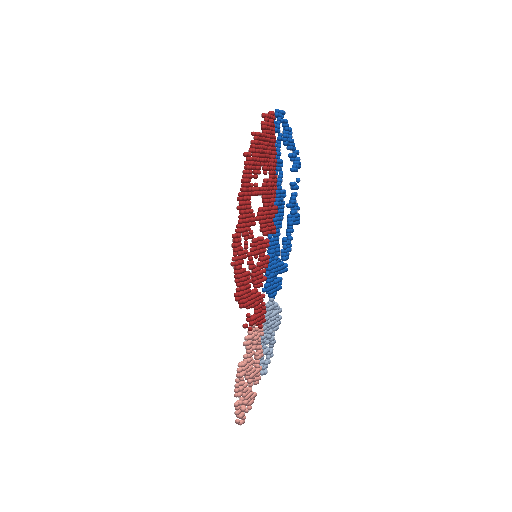

CameraPosition(position=(1861.8655260948804, -3900.5710278071024, 1148.9430379922371),
               focal_point=(661.4129333496094, 1049.88232421875, 760.0),
               viewup=(-0.0016356004190787132, 0.07793148268001909, 0.9969573756277461))

In [27]:
sub_slice = slices[3]
three_d_plot(
    sub_slice,
    key="heart_regions",
    model_size=5,
    model_style="points",
    opacity=1,
    background="white",
    cpo=cpo,
    jupyter="static",
    show_legend=False
    )

### How to get the desired camera position?

Adjust the camera to your preferred angle, then close the window...


/Users/shuilan/Documents/GitHub/UniST/downstream/vis/three_d_plot.py:273: UserWarning: Not within a jupyter notebook environment.
Ignoring ``jupyter_backend``.
  return plotter.show(


<class 'pyvista.plotting.renderer.CameraPosition'>
Saved camera position: [(5410.919769760918, -483.0652626725177, 148.4307973938722),
 (661.4129333496094, 809.88232421875, 760.0),
 (0.12591375630402482, -0.0066976935791876226, 0.9920185819197795)]


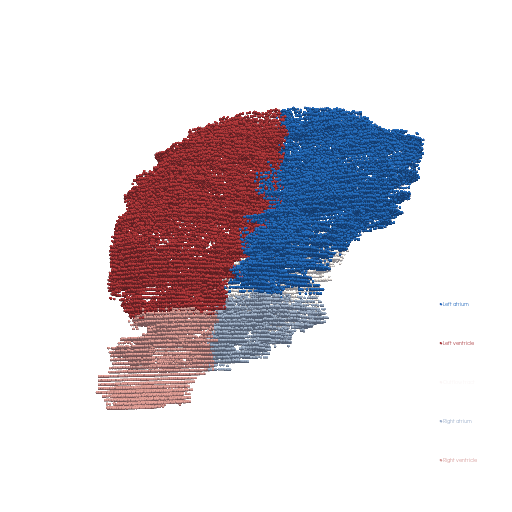

CameraPosition(position=(5410.919769760918, -483.0652626725177, 148.4307973938722),
               focal_point=(661.4129333496094, 809.88232421875, 760.0),
               viewup=(0.1259137563040248, -0.006697693579187621, 0.9920185819197793))

In [7]:
print("Adjust the camera to your preferred angle, then close the window...")

cpo = three_d_plot(
    model=pc,
    key="heart_regions",
    model_size=3,
    model_style="points",
    opacity=1,
    background="white",
    cpo="iso",              
    jupyter=False,         
)

# Save the optimized camera position

print(type(cpo))
print("Saved camera position:", cpo)

# Reload and reuse the saved camera view

three_d_plot(
    model=pc,
    key="heart_regions",
    model_size=3,
    model_style="points",
    opacity=1,
    background="white",
    cpo=cpo,              
    jupyter='static',         
)

Adjust the camera to your preferred angle, then close the window...


/Users/shuilan/Documents/GitHub/UniST/downstream/vis/slice_generation.py:470: UserWarning: Not within a jupyter notebook environment.
Ignoring ``jupyter_backend``.
  return pl.show(return_cpos=True, jupyter_backend=jupyter_backend, cpos=cpo)


<class 'pyvista.plotting.renderer.CameraPosition'>
Saved camera position: [(1861.8655260948804, -3900.5710278071024, 1148.9430379922371),
 (661.4129333496094, 1049.88232421875, 760.0),
 (-0.0016356004190787136, 0.0779314826800191, 0.9969573756277463)]


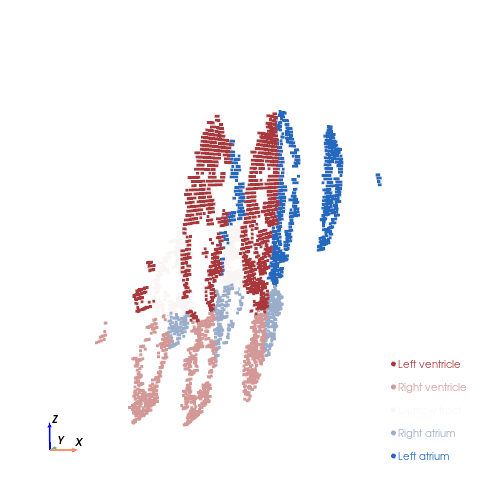

CameraPosition(position=(1861.8655260948804, -3900.5710278071024, 1148.9430379922371),
               focal_point=(661.4129333496094, 1049.88232421875, 760.0),
               viewup=(-0.0016356004190787132, 0.07793148268001909, 0.9969573756277461))

In [19]:
print("Adjust the camera to your preferred angle, then close the window...")

cpo = plot_slice_stack(
    slices,
    key="heart_regions",
    regions_colors=regions_colors,
    point_size=2.5,
    opacity=1.0,
    spacing_axis=1,
    spacing=80.0,
    use_parallel_projection=False,
    window_size=(500, 500),
    show_legend=True,
    jupyter=False,
    cpo = 'iso'      
)

# Save the optimized camera position

print(type(cpo))
print("Saved camera position:", cpo)

plot_slice_stack(
    slices,
    key="heart_regions",
    regions_colors=regions_colors,
    point_size=2.5,
    opacity=1.0,
    spacing_axis=1,
    spacing=80.0,
    use_parallel_projection=False,
    window_size=(500, 500),
    show_legend=True,
    jupyter="static",
    cpo=cpo
)